In [ ]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import pandas
import pandas.core.indexes
import sys
sys.modules['pandas.indexes'] = pandas.core.indexes

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from skimage.transform import resize
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# Paths
reports_path = os.path.expanduser('~/Documents/SemiSight/reports')
models_path = os.path.expanduser('~/Documents/SemiSight/models')
os.makedirs(reports_path, exist_ok=True)

# Load dataset
with open('/Users/zabir/Downloads/LSWMD.pkl', 'rb') as f:
    df = pickle.load(f, encoding='latin1')

print("=" * 40)
print("EVERYTHING LOADED SUCCESSFULLY!")
print("=" * 40)
print(f"Dataset shape: {df.shape}")

## 06 - CNN Wafer Map Analysis

## Steps Completed
1. Loaded WM-811K dataset — 811,457 wafer maps, 6 columns
2. Cleaned failure type labels — extracted from nested lists
3. Filtered to labeled wafers only — 25,519 wafers, 8 failure types
4. Preprocessed wafer maps — resized to 32x32, normalized to 0-1
5. Split data — 80/20 train/test, stratified
6. Computed class weights — handled imbalance (Near-full weight: 21.4)
7. Built CNN — 2 conv blocks, dropout, 315,272 parameters
8. Trained CNN — 11 epochs, early stopping, 2-3s per epoch
9. Evaluated — 83% test accuracy across 8 failure types

## Key Decisions
- Used 32x32 resize — small enough to train fast, large enough to preserve patterns
- BatchNormalization after each conv block — stabilizes training
- Dropout 0.5 — prevents overfitting on dominant classes
- Class weights — stops model ignoring rare classes like Near-full and Scratch
- Early stopping patience=5 — restored best weights from epoch 6

## Results by Failure Type
- Edge-Ring: 0.95 F1 — best performer, largest class
- Center: 0.94 F1 — tight cluster pattern very learnable
- Donut: 0.85 F1 — strong despite only 111 test samples
- Random: 0.79 F1 — good given no real spatial pattern
- Edge-Loc: 0.76 F1 — occasionally confused with Edge-Ring
- Loc: 0.68 F1 — similar appearance to Edge-Loc causes confusion
- Near-full: 0.62 F1 — perfect recall but over-predicts due to high class weight
- Scratch: 0.32 F1 — weakest, only 238 training samples

## Final Data Shape
- Input: 25,519 wafer maps, 32x32x1
- Training: 20,415 wafer maps
- Test: 5,104 wafer maps
- Classes: 8 failure types

In [13]:
import pickle
import pandas
import pandas.core.indexes
import sys
sys.modules['pandas.indexes'] = pandas.core.indexes

import numpy as np
import pandas as pd

with open('/Users/zabir/Downloads/LSWMD.pkl', 'rb') as f:
    df = pickle.load(f, encoding='latin1')

print(f"Type: {type(df)}")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst row:")
print(df.iloc[0])

Type: <class 'pandas.core.frame.DataFrame'>
Shape: (811457, 6)
Columns: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']

First row:
waferMap          [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
dieSize                                                      1683.0
lotName                                                        lot1
waferIndex                                                      1.0
trianTestLabel                                         [[Training]]
failureType                                                [[none]]
Name: 0, dtype: object


In [14]:
# Extract failure type cleanly
df['failureType'] = df['failureType'].apply(lambda x: x[0][0] if len(x) > 0 else 'none')
df['trianTestLabel'] = df['trianTestLabel'].apply(lambda x: x[0][0] if len(x) > 0 else 'unknown')

# Check failure type distribution
print("=== Failure Type Distribution ===")
print(df['failureType'].value_counts())

print(f"\n=== Train/Test Split ===")
print(df['trianTestLabel'].value_counts())

# Filter to labeled wafers only
df_labeled = df[df['failureType'] != 'none']
print(f"\nLabeled wafers: {len(df_labeled)}")
print(f"Unlabeled wafers: {len(df) - len(df_labeled)}")

=== Failure Type Distribution ===
failureType
none         785938
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

=== Train/Test Split ===
trianTestLabel
unknown     638507
Test        118595
Training     54355
Name: count, dtype: int64

Labeled wafers: 25519
Unlabeled wafers: 785938


In [15]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

File size: 42706 bytes ← should be >50000


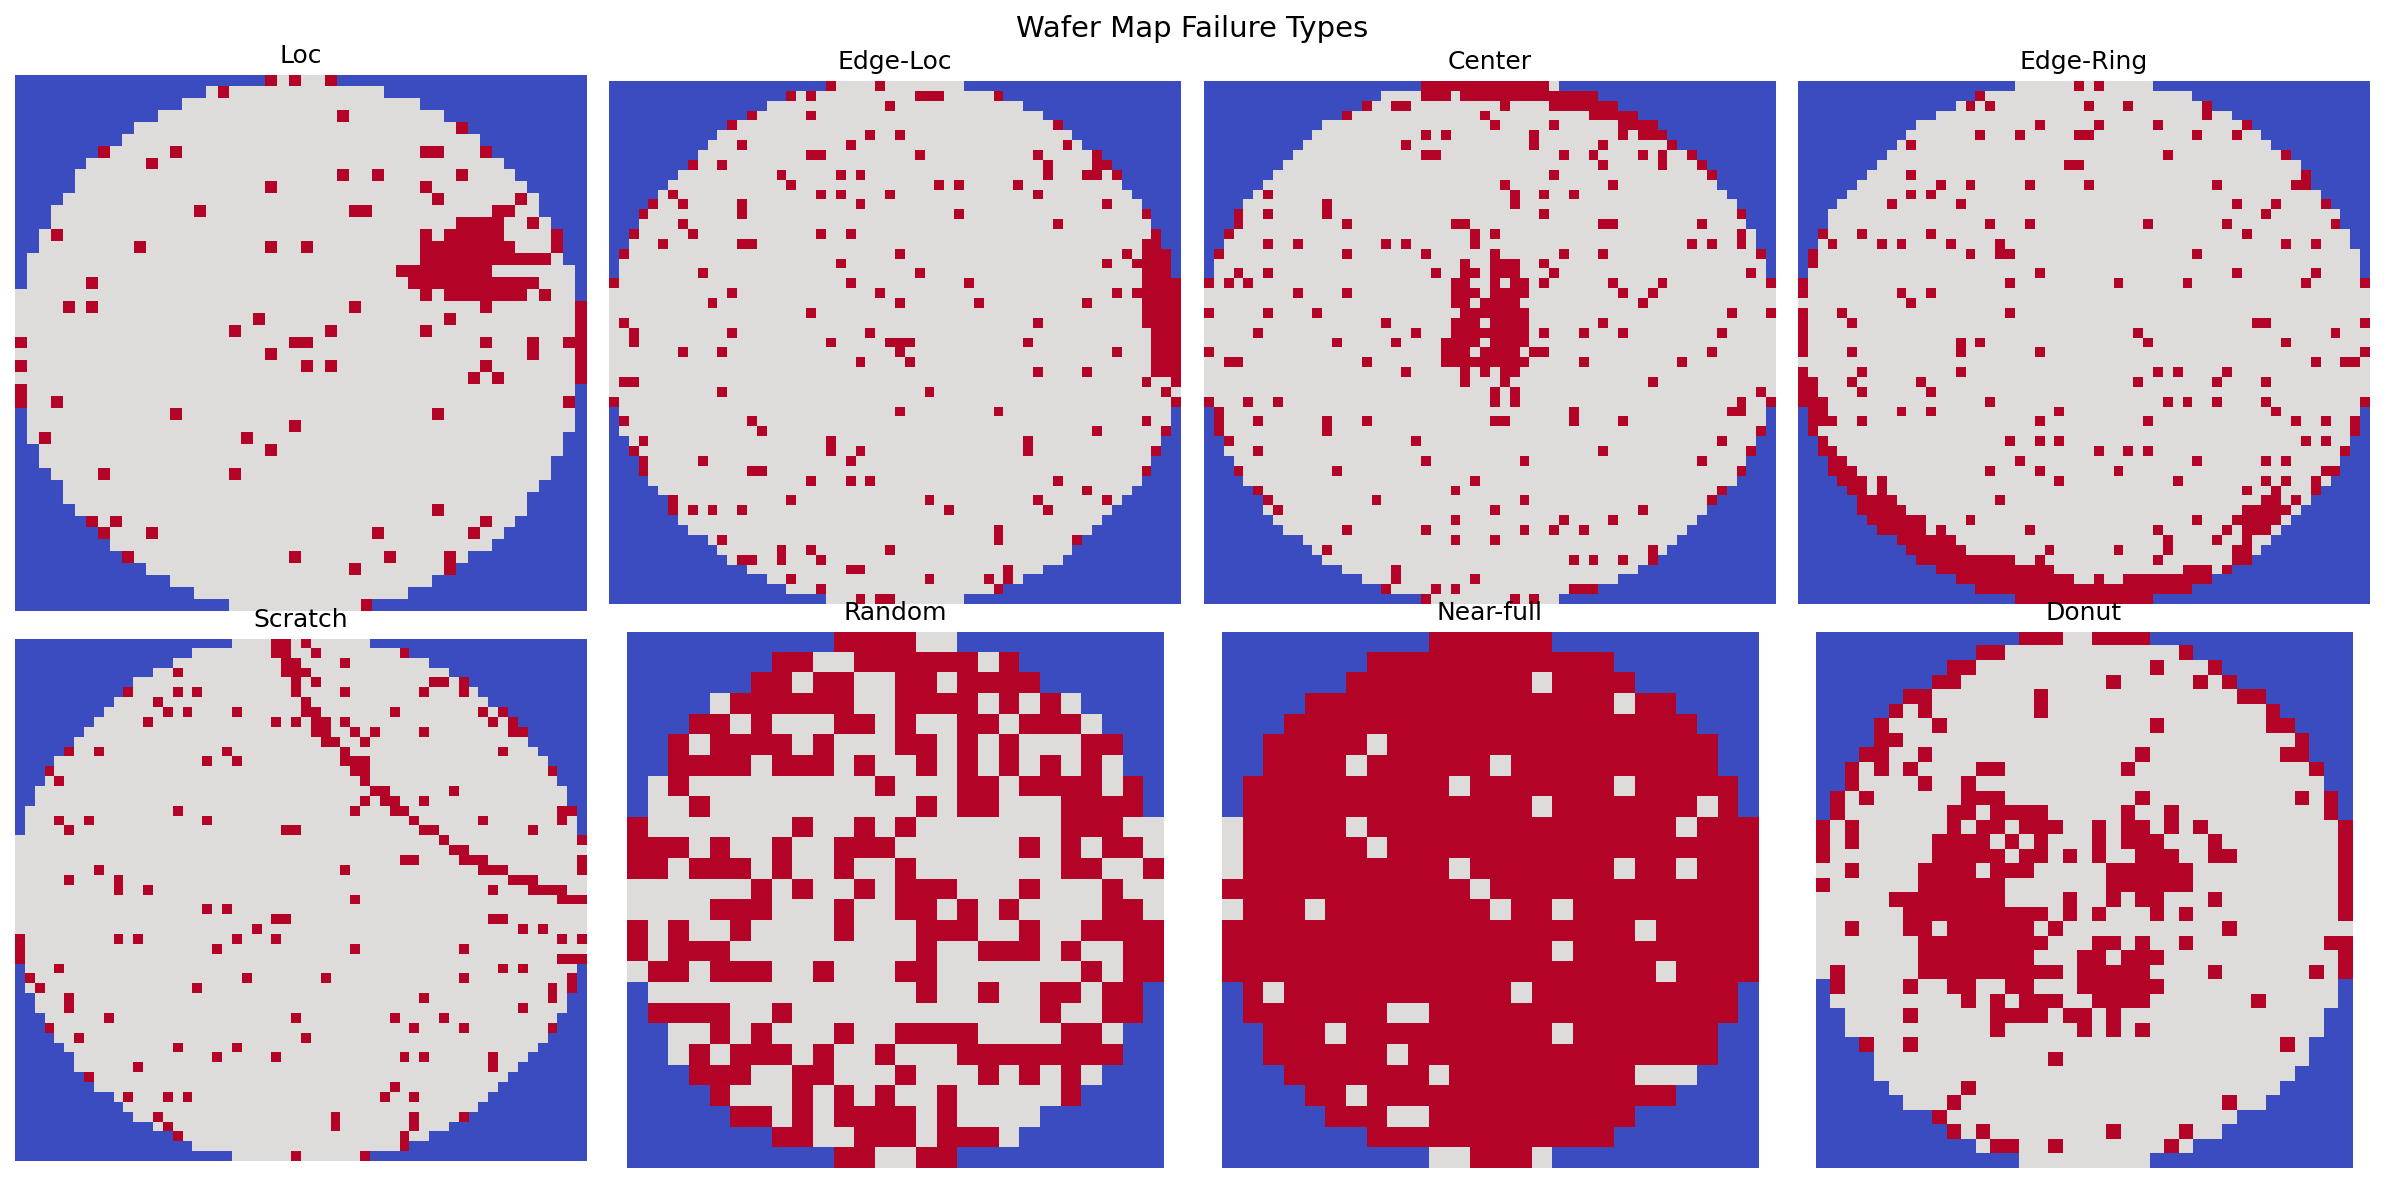

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import os

reports_path = os.path.expanduser('~/Documents/SemiSight/reports')
os.makedirs(reports_path, exist_ok=True)

failure_types = df_labeled['failureType'].unique()
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, ft in enumerate(failure_types):
    sample = df_labeled[df_labeled['failureType'] == ft].iloc[0]['waferMap']
    axes[i].imshow(sample, cmap='coolwarm', interpolation='nearest')
    axes[i].set_title(ft)
    axes[i].axis('off')

plt.suptitle('Wafer Map Failure Types', fontsize=14)
plt.tight_layout()

# Save FIRST, then show
plt.savefig(f'{reports_path}/wafer_map_examples.png', bbox_inches='tight', dpi=150)

# Verify
size = os.path.getsize(f'{reports_path}/wafer_map_examples.png')
print(f"File size: {size} bytes ← should be >50000")

plt.show()

In [17]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from skimage.transform import resize

# Standard size for all wafer maps
IMG_SIZE = 32

def preprocess_wafer(wafer_map):
    # Resize to standard size
    resized = resize(wafer_map.astype(float), 
                    (IMG_SIZE, IMG_SIZE), 
                    anti_aliasing=True)
    # Normalize to 0-1
    resized = resized / 2.0
    return resized

X = np.array([preprocess_wafer(w) for w in df_labeled['waferMap']])
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)  # Add channel dimension for CNN

# Encode labels
le = LabelEncoder()
y = le.fit_transform(df_labeled['failureType'])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Classes: {le.classes_}")

X shape: (25519, 32, 32, 1)
y shape: (25519,)
Classes: [np.str_('Center') np.str_('Donut') np.str_('Edge-Loc')
 np.str_('Edge-Ring') np.str_('Loc') np.str_('Near-full')
 np.str_('Random') np.str_('Scratch')]


In [18]:
from sklearn.model_selection import train_test_split
import numpy as np

# Train/test split — stratified to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")

# Compute class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

print(f"\nClass weights:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls}: {class_weights[i]:.3f}")

X_train shape: (20415, 32, 32, 1)
X_test shape : (5104, 32, 32, 1)

Class weights:
  Center: 0.743
  Donut: 5.747
  Edge-Loc: 0.615
  Edge-Ring: 0.330
  Loc: 0.888
  Near-full: 21.444
  Random: 3.682
  Scratch: 2.672


In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Set seed for reproducibility
tf.random.set_seed(69)

model = models.Sequential([
    # First conv block — detects basic shapes and edges
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 1)),
    layers.MaxPooling2D((2,2)),
    layers.BatchNormalization(),

    # Second conv block — detects more complex patterns
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.BatchNormalization(),

    # Flatten and classify
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(8, activation='softmax')  # 8 failure types
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 15, 15, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 6, 6, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,272 (1.20 MB)

 Trainable params: 315,080 (1.20 MB)

 Non-trainable params: 192 (768.00 B)

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

print("Training complete.")

Epoch 1/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5809 - loss: 1.3607 - val_accuracy: 0.4252 - val_loss: 1.5859
Epoch 2/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7085 - loss: 0.7148 - val_accuracy: 0.6995 - val_loss: 0.7674
Epoch 3/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7493 - loss: 0.6735 - val_accuracy: 0.7301 - val_loss: 0.8650
Epoch 4/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7767 - loss: 0.5732 - val_accuracy: 0.7899 - val_loss: 0.5746
Epoch 5/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7973 - loss: 0.4774 - val_accuracy: 0.8058 - val_loss: 0.5517
Epoch 6/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8103 - loss: 0.4895 - val_accuracy: 0.8207 - val_loss: 0.5250
Epoch 7/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8165 - loss: 0.4705 - val_accuracy: 0.7862 - val_loss: 0.5459
Epoch 8/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8327 - loss: 0.3933 - val_accuracy: 0

Test Accuracy: 0.8595
Test Loss:     0.3828
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Classification Report:
              precision    recall  f1-score   support

      Center       0.95      0.96      0.95       859
       Donut       0.88      0.86      0.87       111
    Edge-Loc       0.77      0.82      0.79      1038
   Edge-Ring       0.99      0.93      0.96      1936
         Loc       0.68      0.74      0.71       719
   Near-full       0.79      1.00      0.88        30
      Random       0.88      0.93      0.90       173
     Scratch       0.47      0.39      0.43       238

    accuracy                           0.86      5104
   macro avg       0.80      0.83      0.81      5104
weighted avg       0.86      0.86      0.86      5104



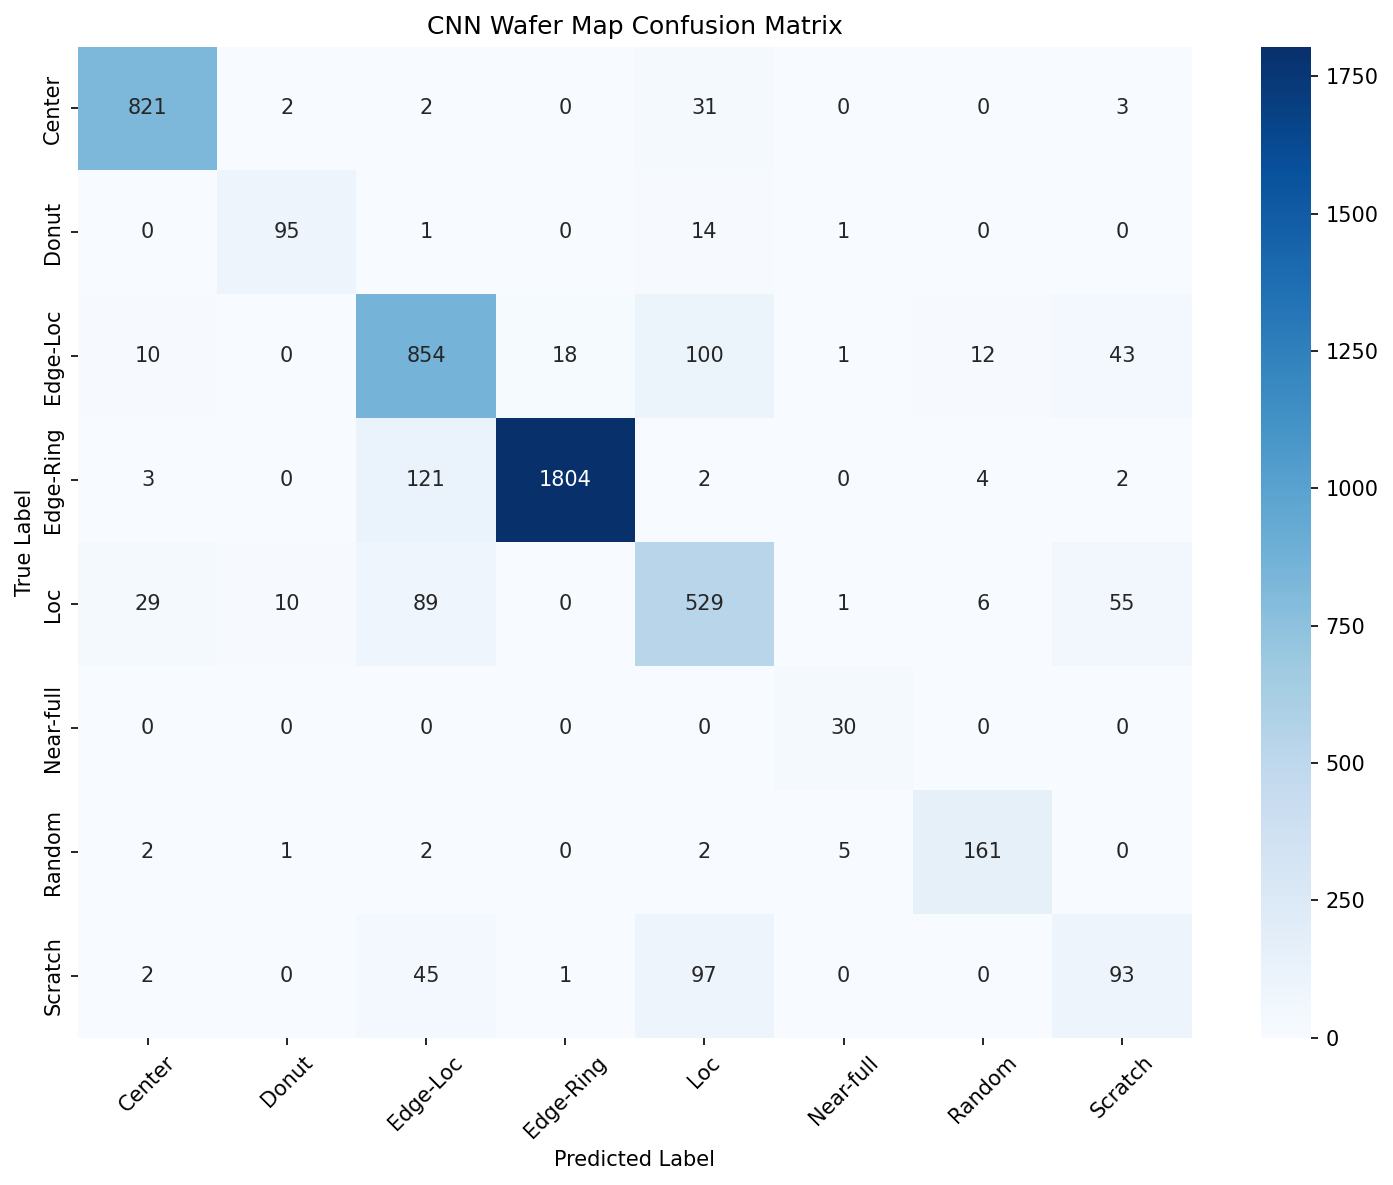

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

# Full classification report
y_pred = np.argmax(model.predict(X_test), axis=1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_,
            cmap='Blues')
plt.title('CNN Wafer Map Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{reports_path}/cnn_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

Model saved.


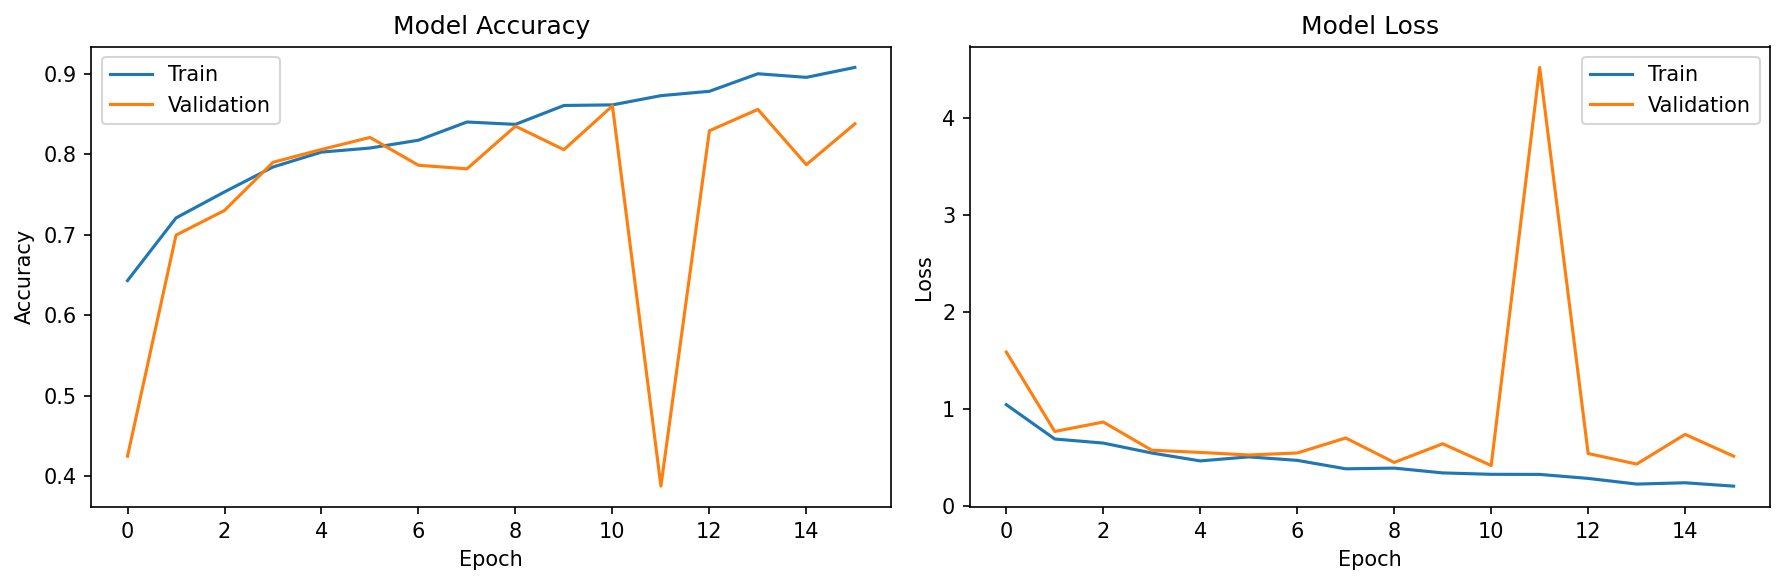

In [24]:
import os

# Save model
models_path = os.path.expanduser('~/Documents/SemiSight/models')
model.save(f'{models_path}/cnn_wafer_map.keras')
print("Model saved.")

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{reports_path}/cnn_training_history.png', bbox_inches='tight', dpi=150)
plt.show()

In [1]:
import numpy as np
import os

BASE_PATH = os.path.expanduser('~/Documents/SemiSight')

# Save wafer maps and labels as numpy arrays
wafer_maps = np.array([preprocess_wafer(w) for w in df_labeled['waferMap']])
wafer_labels = df_labeled['failureType'].values

np.save(f'{BASE_PATH}/data/processed/wafer_maps.npy', wafer_maps)
np.save(f'{BASE_PATH}/data/processed/wafer_labels.npy', wafer_labels)

print(f"Wafer maps saved: {wafer_maps.shape}")
print(f"Wafer labels saved: {wafer_labels.shape}")

NameError: name 'df_labeled' is not defined